Libreria


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [41]:
def save_data(filename, data1, data2, header1="Column 1", header2="Column 2"):
    """
    Salva due array di dati in un file di testo con due colonne.

    Parameters:
    filename (str): Nome del file di output.
    data1 (numpy array): Primo array di dati.
    data2 (numpy array): Secondo array di dati.
    header1 (str): Intestazione della prima colonna.
    header2 (str): Intestazione della seconda colonna.

    Output:
    Un file di testo con due colonne: data1 e data2.
    """
    data_to_save = np.column_stack((data1, data2))  # Combina i dati in due colonne
    header = f"{header1}   {header2}"  # Crea l'intestazione dinamicamente
    np.savetxt(filename, data_to_save, fmt="%.6e", header=header, comments='')






In [19]:


# Distanza 1Mpc
d = 1 * 3.086e24  # cm
d_m = 1 * 3.086e22  # m per calcrate


# Caricamento dati
data = np.loadtxt("SN_IIP/SNIIP_20_block_20.dat", skiprows=1)

# Definizione MRF
MRF = [6.1921, 6.1921, 6.1623, 6.1807, 6.1601,
    7.9761, 8.9815, 9.6370, 10.1817, 10.9682, 11.7444, 12.6063, 14.2297, 15.5405]

# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12 # eV

# Controllo se ci sono abbastanza dati
if data.shape[1] > 7:
    Ev_all = data[:, 0]  # Energia in eV
    dN_dEv = data[:, 7]  # Spettro

    # Selezione dei valori vicini a 1 TeV per il modello (M)
    Ev_mask = np.isclose(Ev_all, E_fixed)
    Ev_M = Ev_all[Ev_all==E_fixed]
    dN_dEv_M = dN_dEv[Ev_all==E_fixed]
    
    Ev = Ev_all[Ev_all>0.3e8]/1e9
    dN_dEv = dN_dEv[Ev_all>0.3e8]

    # Se il valore di Ev è vuoto, segnala errore
    if Ev.size == 0:
        print("Errore: Nessun valore di Ev corrisponde a 1 TeV!")
    else:
        # Calcolo intervallo delta tra i blocchi
        S_IIP_start = 1e3 * 10**(0.1 * (9 - 1))
        S_IIP_stop = 1e3 * 10**(0.1 * (26 - 1))
        delta = S_IIP_stop - S_IIP_start

        # Calcolo del flusso
        #dN_dEv *= delta
        flux_c = dN_dEv * 1e9 / (6 * 4 * np.pi * d_m**2)
        flux = Ev_M**2 * dN_dEv_M / (1e9 * 3 * 4 * np.pi * d**2)
        
        # Sensibilità
        sensitivity = flux * MRF
        #save_data("flux_IIp.txt", Ev, flux_c, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")



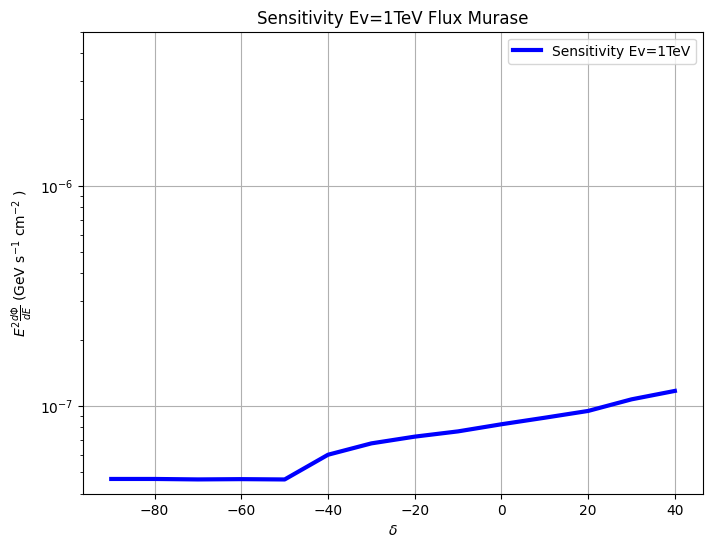

In [22]:

# Definizione degli angoli δ
delta_list = np.linspace(-90, 40, len(MRF))
#sin_delta = np.sin(np.radians(delta_list))

# Plot 1: Sensibilità (Flux Murase)
plt.figure(figsize=(8, 6))
plt.plot(delta_list, sensitivity, color='b',linewidth=3, label="Sensitivity Ev=1TeV")
plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")
plt.ylim(4e-8,5e-6)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Flux Murase')
plt.legend()
plt.show()



print()


In [26]:


# Distanza 1Mpc
d = 1 * 3.086e24  # cm
d_m = 1 * 3.086e22  # m per calcrate


# Caricamento dati
data = np.loadtxt("SN_IIP/SNIIP_20_block_20.dat", skiprows=1)

# Definizione MRF
MRF = [6.1921, 6.1921, 6.1623, 6.1807, 6.1601,
    7.9761, 8.9815, 9.6370, 10.1817, 10.9682, 11.7444, 12.6063, 14.2297, 15.5405]

# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12 # eV

# Controllo se ci sono abbastanza dati
if data.shape[1] > 7:
    Ev_all = data[:, 0]  # Energia in eV
    dN_dEv = data[:, 7]  # Spettro

    # Selezione dei valori vicini a 1 TeV per il modello (M)
    Ev_mask = np.isclose(Ev_all, E_fixed)
    Ev_M = Ev_all[Ev_all==E_fixed]
    dN_dEv_M = dN_dEv[Ev_all==E_fixed]
    
    Ev = Ev_all[Ev_all>0.3e8]/1e9
    dN_dEv = dN_dEv[Ev_all>0.3e8]

    # Se il valore di Ev è vuoto, segnala errore
    if Ev.size == 0:
        print("Errore: Nessun valore di Ev corrisponde a 1 TeV!")
    else:
        # Calcolo intervallo delta tra i blocchi
        S_IIP_start = 1e3 * 10**(0.1 * (20 - 1))
        S_IIP_stop = 1e3 * 10**(0.1 * (29 - 1))
        delta = S_IIP_stop - S_IIP_start

        # Calcolo del flusso
        #dN_dEv *= delta
        flux_c = dN_dEv * 1e9 / (6 * 4 * np.pi * d_m**2)
        flux = Ev_M**2 * dN_dEv_M / (1e9 * 3 * 4 * np.pi * d**2)
        
        # Sensibilità
        #sensitivity = flux * MRF
        save_data("flux_IIp_1_notime.txt", Ev, flux_c, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")



In [49]:


# Distanza 1Mpc
d = 1 * 3.086e24  # cm
d_m = 1 * 3.086e22  # m per calcrate


# Caricamento dati
data = np.loadtxt("SN_IIP/SNIIP_20_block_30.dat", skiprows=1)

# Definizione MRF
#MRF = [6.1921, 6.1921, 6.1623, 6.1807, 6.1601,7.9761, 8.9815, 9.6370, 10.1817, 10.9682, 11.7444, 12.6063, 14.2297, 15.5405]

# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12 # eV

# Controllo se ci sono abbastanza dati
if data.shape[1] > 7:
    Ev_all = data[:, 0]  # Energia in eV
    dN_dEv = data[:, 7]  # Spettro

    # Selezione dei valori vicini a 1 TeV per il modello (M)
    Ev_mask = np.isclose(Ev_all, E_fixed)
    Ev_M = Ev_all[Ev_all==E_fixed]
    dN_dEv_M = dN_dEv[Ev_all==E_fixed]
    
    Ev = Ev_all[Ev_all>0.3e8]/1e9
    dN_dEv = dN_dEv[Ev_all>0.3e8]

    # Se il valore di Ev è vuoto, segnala errore
    if Ev.size == 0:
        print("Errore: Nessun valore di Ev corrisponde a 1 TeV!")
    else:
        # Calcolo intervallo delta tra i blocchi
        S_IIP_start = 1e3 * 10**(0.1 * (41.5 - 1))
        S_IIP_stop = 1e3 * 10**(0.1 * (46.5 - 1))
        delta = S_IIP_stop - S_IIP_start

        # Calcolo del flusso
        #dN_dEv *= delta
        flux_c = dN_dEv * 1e9 / (6 * 4 * np.pi * d_m**2)
        flux = Ev_M**2 * dN_dEv_M / (1e9 * 3 * 4 * np.pi * d**2)
        
        # Sensibilità
        #sensitivity = flux * MRF
        save_data("flux_IIp_2_jnh.txt", Ev, flux_c, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")



In [6]:
data_new_1 = np.loadtxt("flux_IIp_1.txt", skiprows=1)
data_new_2 = np.loadtxt("flux_IIp_2.txt", skiprows=1)

fluence_1 =  data_new_1[:,1]
fluence_2 =  data_new_2[:,1]
Ev =  data_new_1[:,0]

fluence_tot = fluence_1 + fluence_2

time_int = 1e3 * 10**(0.1 * (51 - 1)) - 1e3 * 10**(0.1 * (20 - 1))

flux_tot = fluence_tot / time_int

#save_data("flux_IIp_tot.txt", Ev, flux_tot,header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]" )

Sensitivity 1 yr with average flux

In [7]:
data_tot =  np.loadtxt("flux_IIp_tot.txt", skiprows=1)

E_fixed = 1.07461e3
Ev_tot = data_tot[:,0]
dN_dEv_tot = data_tot[:,1]
Ev = Ev_tot[Ev_tot==E_fixed]
dN_dEv= dN_dEv_tot[Ev_tot==E_fixed]

flux_tot = Ev**2 *  dN_dEv * 2 * d_m**2 / d**2 * 1/3

MRF_tot = [
    1107.23, 1107.23, 1102.64, 1105.16, 1101.64,
    1426.24, 1605.98, 1723.22, 1820.72, 1961.14,
    2100.58, 2258.54, 2545.77, 2780.51
]


sensitivity_weighted = flux_tot *  MRF_tot


In [12]:

# Definizione degli angoli δ
delta_list = np.linspace(-90, 40, len(MRF_tot))
#sin_delta = np.sin(np.radians(delta_list))

# Plot 1: Sensibilità (Flux Murase)
plt.figure(figsize=(8, 6))
plt.plot(delta_list, sensitivity_weighted, color='orange', linewidth=3, label="Sensitivity Ev=1TeV")
plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")
plt.ylim(1e-8,5e-6)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Flux Murase - weighted')
plt.legend()
plt.show()



print()


NameError: name 'MRF_tot' is not defined

Sensitivity 3 yr with average flux

In [10]:
# Distanza 1Mpc
d = 1 * 3.086e24  # cm
d_m = 1 * 3.086e22  # m per calcrate
data_tot =  np.loadtxt("flux_IIp_tot.txt", skiprows=1)

E_fixed = 1.07461e3
Ev_tot = data_tot[:,0]
dN_dEv_tot = data_tot[:,1]
Ev = Ev_tot[Ev_tot==E_fixed]
dN_dEv= dN_dEv_tot[Ev_tot==E_fixed]

flux_tot = Ev**2 *  dN_dEv * 2 * d_m**2 / d**2


#aanet 2.7
MRF_tot_3 = [409.836, 409.836, 410.188, 413.319, 414.32, 524.32, 585.229, 623.507, 654.17, 698.702, 744.415, 797.104, 894.177, 975.082]
#aanet 2.6
mrf_values_2_6 = [
    411.606, 411.606, 411.963, 415.104, 416.059,
    527.359, 587.744, 626.697, 657.126, 701.741,
    746.632, 799.674, 896.743, 977.862
]


sensitivity_weighted_3 = flux_tot *  MRF_tot_3

sensitivity_weighted_26 = flux_tot *  mrf_values_2_6


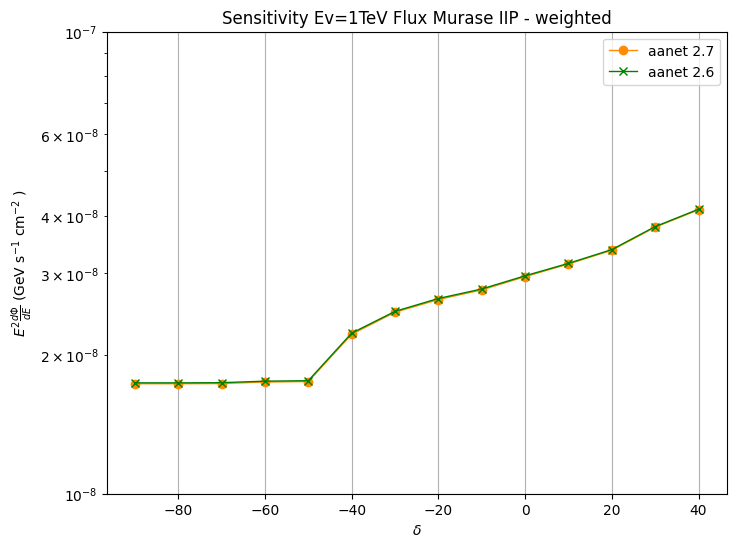

In [ ]:

# Definizione degli angoli δ
delta_list = np.linspace(-90, 40, len(MRF_tot_3))
#sin_delta = np.sin(np.radians(delta_list))

# Plot 1: Sensibilità (Flux Murase)
plt.figure(figsize=(8, 6))
plt.plot(delta_list, sensitivity_weighted_3,marker='o', color='darkorange', linewidth=1, label="aanet 2.7")
plt.plot(delta_list, sensitivity_weighted_26,marker='x', color='green', linewidth=1, label="aanet 2.6")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")
plt.ylim(1e-8,1e-7)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Flux Murase IIP - weighted')
plt.legend()
plt.show()



print()


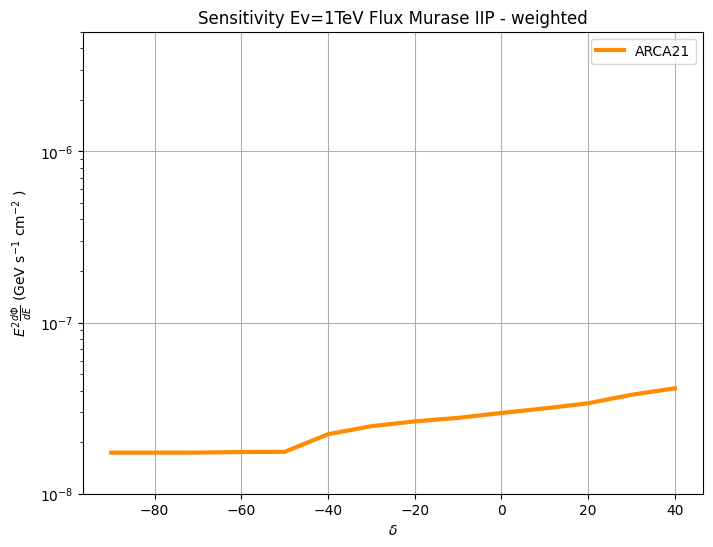

In [14]:

# Definizione degli angoli δ
delta_list = np.linspace(-90, 40, len(MRF_tot_3))
#sin_delta = np.sin(np.radians(delta_list))

# Plot 1: Sensibilità (Flux Murase)
plt.figure(figsize=(8, 6))
#plt.plot(delta_list, sensitivity_weighted_3,marker='o', color='darkorange', linewidth=1, label="aanet 2.7")
plt.plot(delta_list, sensitivity_weighted_26,linewidth=3, color='darkorange',  label="ARCA21")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")
plt.ylim(1e-8,5e-6)

plt.grid(True)
plt.title('Sensitivity Ev=1TeV Flux Murase IIP - weighted')
plt.legend()
plt.show()



print()


3.267682e-05


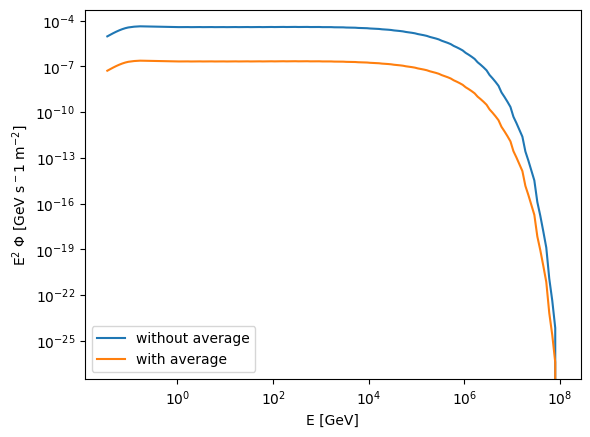

In [2]:
import numpy as np
import matplotlib.pyplot as plt
data = np.loadtxt('flux_IIp.txt', skiprows=1)
e =  data[:,0]
f = data[:,1]
plt.plot(e,e**2*f, label='without average')
data2 = np.loadtxt('flux_IIp_tot.txt', skiprows=1)
e2 =  data2[:,0]
f2 = data2[:,1]
plt.plot(e2,e2**2*f2, label='with average')
plt.xlabel('E [GeV]')
#plt.xlim(1e-1,1e6)
print(data[24,1])
#plt.title('SN2023erg')
plt.ylabel(r'E$^{2}$ $\Phi$ [GeV s$^-1$ m$^{-2}$]')
plt.xscale('log')
plt.yscale('log')
plt.legend()

In [45]:
def save_data(filename, x, y, header1="", header2=""):
    header = f"{header1}\t{header2}"
    data = np.column_stack((x, y))
    np.savetxt(filename, data, header=header)

In [45]:
sn_sources = {
    'SN2023pnt': {'d_cm': 141.9 * 3.086e24, 'd_m': 141.9 * 3.086e22, 'MRF': 1.49892e07, 'dec': 10, 'MDP':1.95342e07},
    'SN2023nca': {'d_cm': 98.4 * 3.086e24, 'd_m': 98.4 * 3.086e22, 'MRF': 9057.64, 'dec': 11,'MDP':11804.1},
    'SN2023lkg': {'d_cm': 135.1 * 3.086e24, 'd_m': 135.1 * 3.086e22, 'MRF': 15004.1, 'dec': -9,'MDP':24336.4},
    'SN2023ewp': {'d_cm': 118.2 * 3.086e24, 'd_m': 118.2 * 3.086e22, 'MRF': 12266.9, 'dec': 0,'MDP':20652.8 },
    'SN2023dxl': {'d_cm': 104.5 * 3.086e24, 'd_m': 104.5 * 3.086e22, 'MRF': 12777.7 , 'dec': 34, 'MDP':17425.4},
    'SN2023czc': {'d_cm': 131.9 * 3.086e24, 'd_m': 131.9 * 3.086e22, 'MRF': 1.24066e07, 'dec': 5,'MDP':2.09483e07},
    'SN2023cmg': {'d_cm': 688.3 * 3.086e24, 'd_m': 688.3 * 3.086e22, 'MRF': 3.00381e08, 'dec': -15,'MDP':4.83509e08},
    'SN2023bbo': {'d_cm': 217.5 * 3.086e24, 'd_m': 217.5 * 3.086e22, 'MRF': 4.08555e07, 'dec': 27,'MDP':5.55383e07},
    'SN2023avk': {'d_cm': 126.7 * 3.086e24, 'd_m': 126.7 * 3.086e22, 'MRF': 1.22077e07, 'dec': 13,'MDP':1.59504e07},
    'SN2023apm': {'d_cm': 68.4 * 3.086e24, 'd_m': 68.4 * 3.086e22, 'MRF': 3.82155e06, 'dec': 21,'MDP':3.55881e07 },
    'SN2023aeh': {'d_cm': 193.9 * 3.086e24, 'd_m': 193.9 * 3.086e22, 'MRF': 2.73832e07, 'dec': 8,'MDP':3.55881e07 },
    'SN2023fu': {'d_cm': 69.4 * 3.086e24, 'd_m': 69.4 * 3.086e22, 'MRF': 4.48465e06, 'dec': 36,'MDP':6.1159e06 },
    'SN2022acko': {'d_cm': 22.2 * 3.086e24, 'd_m': 22.2 * 3.086e22, 'MRF': 307289, 'dec': -19,'MDP': 480939},
    'SN2022aang': {'d_cm': 66.4 * 3.086e24, 'd_m': 66.4 * 3.086e22, 'MRF': 3.5144e06, 'dec': 18,'MDP':4.61041e06},
    'SN2022aaiy': {'d_cm': 147.8 * 3.086e24, 'd_m': 147.8 * 3.086e22, 'MRF': 1.8866e07, 'dec': 29,'MDP':2.56462e07},
    'SN2022wma': {'d_cm': 132.6 * 3.086e24, 'd_m': 132.6 * 3.086e22, 'MRF': 1.22851e07, 'dec': 2,'MDP': 2.06834e07 },
    'SN2022qze': {'d_cm': 34.8 * 3.086e24, 'd_m': 34.8 * 3.086e22, 'MRF': 965324 , 'dec': 19,'MDP':1.26637e06 },
    'SN2022jnh': {'d_cm': 168.9 * 3.086e24, 'd_m': 168.9 * 3.086e22, 'MRF': None , 'dec': 5 ,'MDP':None}
    }


In [47]:
# Caricamento dati dal file
data = np.loadtxt("flux_IIp_tot.txt", skiprows=1)

# Estrazione dati dallo spettro
Ev_all = data[:, 0]        # Energia in eV
dN_dEv_all = data[:, 1]      # Spettro

# Selezione dei dati a bassa energia (per il calcolo di flux_c)
Ev_c = Ev_all  # in GeV
dN_dEv_c = dN_dEv_all

E_fixed = 1.07461e3
# Selezione dei valori vicini a 1 TeV
mask_fixed = np.isclose(Ev_all, E_fixed)
Ev = Ev_all[Ev_all==E_fixed]
dN_dEv = dN_dEv_all[Ev_all==E_fixed]

flux_c = Ev**2 * dN_dEv / (3 * 4 * np.pi * d**2)
    
#sensitivity_model = flux_c * MRF_tot
# Funzioni per il calcolo del flux:
# flux_calculation usa la distanza in cm, mentre flux_c usa la distanza in m
def flux_calc(Ev_val, dN_dEv_val, d_cm):
    return (Ev_val**2 * 2 * dN_dEv_val * 3.086e22**2) / ( d_cm**2)

def flux_c_calc(dN_dEv_vals, d_m):
    return (dN_dEv_vals*3.086e22**2) / (d_m**2)

# Calcolo flux e flux_c per ciascuna sorgente
results = {}
for sn, params in sn_sources.items():
    f = flux_calc(Ev, dN_dEv, params['d_cm'])
    f_c = flux_c_calc(dN_dEv_c, params['d_m'])
    results[sn] = {'flux': f, 'flux_c': f_c}

# Generazione automatica del nome del file: "flux_c_<nome_supernova>.txt"
    filename = f"flux_c_{sn}.txt"
    save_data(filename, Ev_c, f_c, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")
    print(f"Dati salvati in {filename}")

Dati salvati in flux_c_SN2023pnt.txt
Dati salvati in flux_c_SN2023nca.txt
Dati salvati in flux_c_SN2023lkg.txt
Dati salvati in flux_c_SN2023ewp.txt
Dati salvati in flux_c_SN2023dxl.txt
Dati salvati in flux_c_SN2023czc.txt
Dati salvati in flux_c_SN2023cmg.txt
Dati salvati in flux_c_SN2023bbo.txt
Dati salvati in flux_c_SN2023avk.txt
Dati salvati in flux_c_SN2023apm.txt
Dati salvati in flux_c_SN2023aeh.txt
Dati salvati in flux_c_SN2023fu.txt
Dati salvati in flux_c_SN2022acko.txt
Dati salvati in flux_c_SN2022aang.txt
Dati salvati in flux_c_SN2022aaiy.txt
Dati salvati in flux_c_SN2022wma.txt
Dati salvati in flux_c_SN2022qze.txt
Dati salvati in flux_c_SN2022jnh.txt


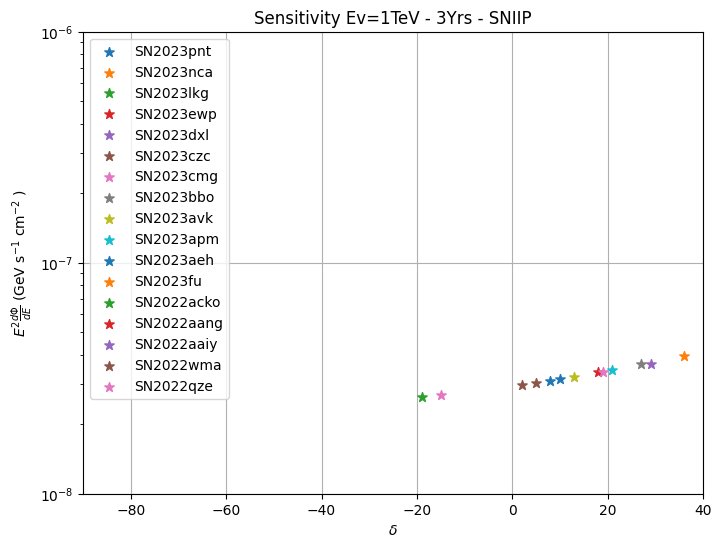

In [74]:
# Preparazione del plot
plt.figure(figsize=(8, 6))
plt.yscale("log")

# Plot delle sorgenti con scatter
for sn, params in sn_sources.items():
    # Si utilizza il flux calcolato e il moltiplicatore specificato per ottenere il valore da plottare
    y_val = np.array(results[sn]['flux'] * params['MRF'])
    x_val = np.array(params['dec'])
    plt.scatter(x_val, y_val, marker='*', s=50, zorder=3, label=sn)
    #plt.text(x_val, y_val * 1.1, sn, fontsize=8, color='blue', ha='right')

# Plot della sensibilità per SN2023esp (linea rossa)
#plt.plot(delta_list, sensitivity_weighted, color='red', label="Sensitivity Ev=1TeV")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.ylim(1e-8,1e-6)
plt.xlim(-90,40)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV - 3Yrs - SNIIP')
plt.legend()
plt.show()


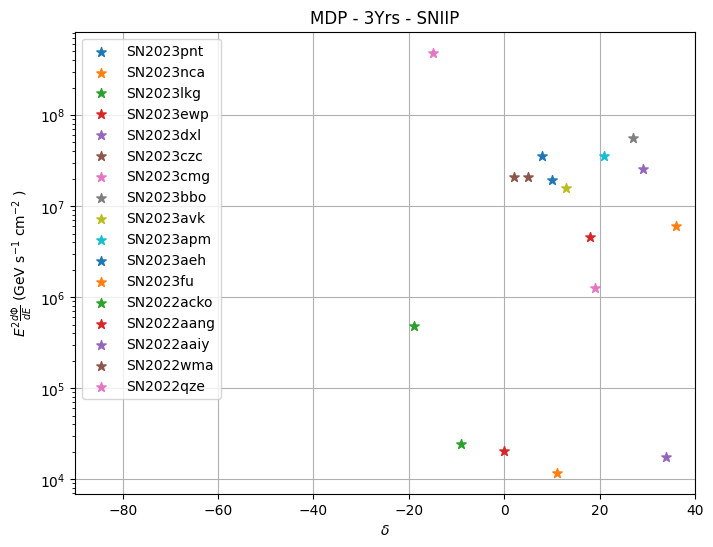

In [78]:
# Preparazione del plot
plt.figure(figsize=(8, 6))
plt.yscale("log")

# Plot delle sorgenti con scatter
for sn, params in sn_sources.items():
    # Si utilizza il flux calcolato e il moltiplicatore specificato per ottenere il valore da plottare
    y_val = np.array(params['MDP'])
    x_val = np.array(params['dec'])
    plt.scatter(x_val, y_val, marker='*', s=50, zorder=3, label=sn)
    #plt.text(x_val, y_val * 1.1, sn, fontsize=8, color='blue', ha='right')

# Plot della sensibilità per SN2023esp (linea rossa)
#plt.plot(delta_list, sensitivity_weighted, color='red', label="Sensitivity Ev=1TeV")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
#plt.ylim(1e-8,1e-6)
plt.xlim(-90,40)
plt.grid(True)
plt.title('MDP - 3Yrs - SNIIP')
plt.legend()
plt.show()


ARCA21

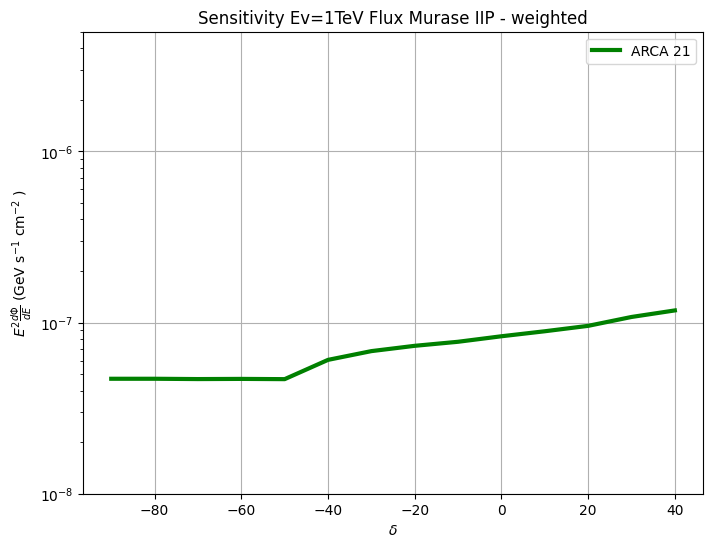

In [30]:
# Distanza 1Mpc
d = 1 * 3.086e24  # cm
d_m = 1 * 3.086e22  # m per calcrate
data_tot =  np.loadtxt("flux_IIp_tot.txt", skiprows=1)

E_fixed = 1.07461e3
Ev_tot = data_tot[:,0]
dN_dEv_tot = data_tot[:,1]
Ev = Ev_tot[Ev_tot==E_fixed]
dN_dEv= dN_dEv_tot[Ev_tot==E_fixed]

flux_tot = Ev**2 *  dN_dEv * 2 * d_m**2 / d**2


MRF_ARCA21 = [
    1112.01, 1112.01, 1107.41, 1109.94, 1106.27,
    1433.78, 1612.84, 1732.12, 1828.97, 1969.73,
    2106.74,2265.77, 2553.24, 2788.42
]

sensitivity_arca21 =  flux_tot * MRF_ARCA21



# Definizione degli angoli δ
delta_list = np.linspace(-90, 40, len(MRF_tot_3))
#sin_delta = np.sin(np.radians(delta_list))

# Plot 1: Sensibilità (Flux Murase)
plt.figure(figsize=(8, 6))
plt.plot(delta_list, sensitivity_arca21, color='green', linewidth=3, label="ARCA 21")
#plt.plot(delta_list, sensitivity_weighted_26,marker='x', color='green', linewidth=1, label="ARCA 21")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")
plt.ylim(1e-8,5e-6)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Flux Murase IIP - weighted')
plt.legend()
plt.show()



print()

mrf = [
    1112.01, 1112.01, 1107.41, 1109.94, 1106.27,
    1433.78, 1505.5, 1732.12, 1969.73, 1969.73,
    2265.77, 2553.24, 2788.42
]


ARCA 8

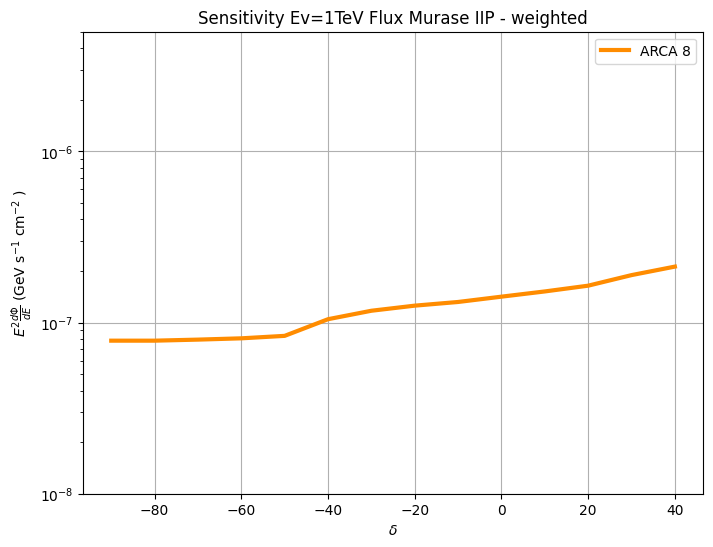

In [18]:
# Distanza 1Mpc
d = 1 * 3.086e24  # cm
d_m = 1 * 3.086e22  # m per calcrate
data_tot =  np.loadtxt("flux_IIp_tot.txt", skiprows=1)

E_fixed = 1.07461e3
Ev_tot = data_tot[:,0]
dN_dEv_tot = data_tot[:,1]
Ev = Ev_tot[Ev_tot==E_fixed]
dN_dEv= dN_dEv_tot[Ev_tot==E_fixed]

flux_tot = Ev**2 *  dN_dEv * 2 * d_m**2 / d**2


MRF_ARCA8 = [1856.24, 1856.24, 1882.76, 1915.69, 1980.35, 2477.56, 2776.11, 2973.2, 3123.77, 3355.15, 3599.4, 3889.66, 4483.47, 5027.17
]

sensitivity_arca8 =  flux_tot * MRF_ARCA8



# Definizione degli angoli δ
delta_list = np.linspace(-90, 40, len(MRF_tot_3))
#sin_delta = np.sin(np.radians(delta_list))

# Plot 1: Sensibilità (Flux Murase)
plt.figure(figsize=(8, 6))
plt.plot(delta_list, sensitivity_arca8, color='darkorange', linewidth=3, label="ARCA 8")
#plt.plot(delta_list, sensitivity_weighted_26,marker='x', color='green', linewidth=1, label="ARCA 21")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")
plt.ylim(1e-8,5e-6)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Flux Murase IIP - weighted')
plt.legend()
plt.show()



print()


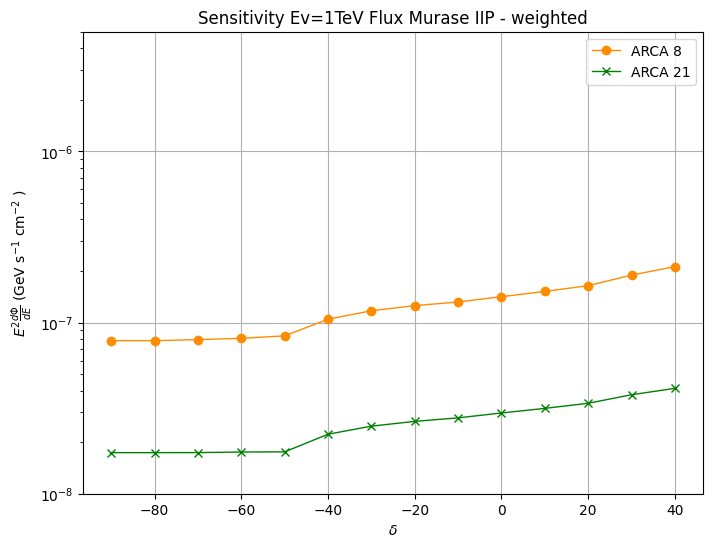

In [19]:
# Plot 1: Sensibilità (Flux Murase)
plt.figure(figsize=(8, 6))
plt.plot(delta_list, sensitivity_arca8, marker='o', color='darkorange', linewidth=1, label="ARCA 8")
plt.plot(delta_list, sensitivity_weighted_26,marker='x', color='green', linewidth=1, label="ARCA 21")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")
plt.ylim(1e-8,5e-6)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Flux Murase IIP - weighted')
plt.legend()
plt.show()

ARCA19


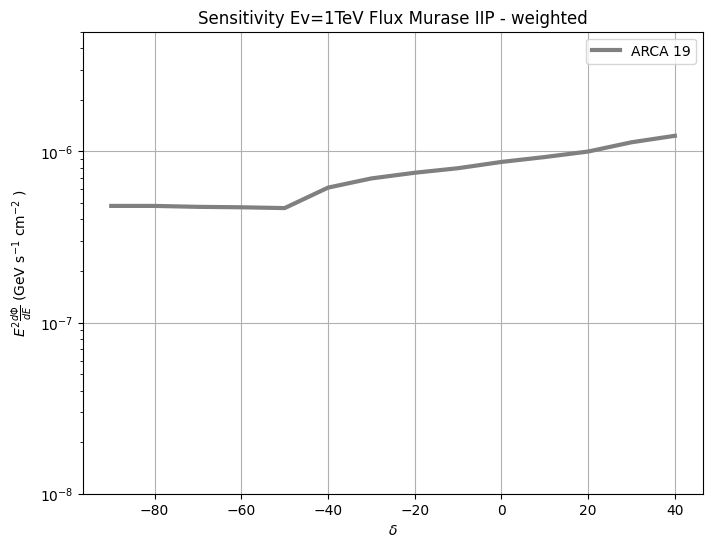

In [28]:
# Distanza 1Mpc
d = 1 * 3.086e24  # cm
d_m = 1 * 3.086e22  # m per calcrate
data_tot =  np.loadtxt("flux_IIp_tot.txt", skiprows=1)

E_fixed = 1.07461e3
Ev_tot = data_tot[:,0]
dN_dEv_tot = data_tot[:,1]
Ev = Ev_tot[Ev_tot==E_fixed]
dN_dEv= dN_dEv_tot[Ev_tot==E_fixed]

flux_tot = Ev**2 *  dN_dEv * 2 * d_m**2 / d**2

#3years
#MRF_ARCA19 = [440.49, 440.49, 438.91, 439.876, 438.769, 558.472, 623.225, 665.718, 700.341, 751.909, 796.954, 852.362, 960.09, 1043.75]

#Real life time (1 mese e mezzo)
MRF_ARCA19 = [
    11372, 11372, 11232, 11165.8, 11044.8,
    14543.6, 16460.8, 17765.8, 18887, 20546.6,
    21946, 23634.5, 26767.9, 29210.6
]


sensitivity_arca19 =  flux_tot * MRF_ARCA19



# Definizione degli angoli δ
delta_list = np.linspace(-90, 40, len(MRF_tot_3))
#sin_delta = np.sin(np.radians(delta_list))

# Plot 1: Sensibilità (Flux Murase)
plt.figure(figsize=(8, 6))
plt.plot(delta_list, sensitivity_arca19, color='grey', linewidth=3, label="ARCA 19")
#plt.plot(delta_list, sensitivity_weighted_26,marker='x', color='green', linewidth=1, label="ARCA 21")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")
plt.ylim(1e-8,5e-6)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Flux Murase IIP - weighted')
plt.legend()
plt.show()



print()


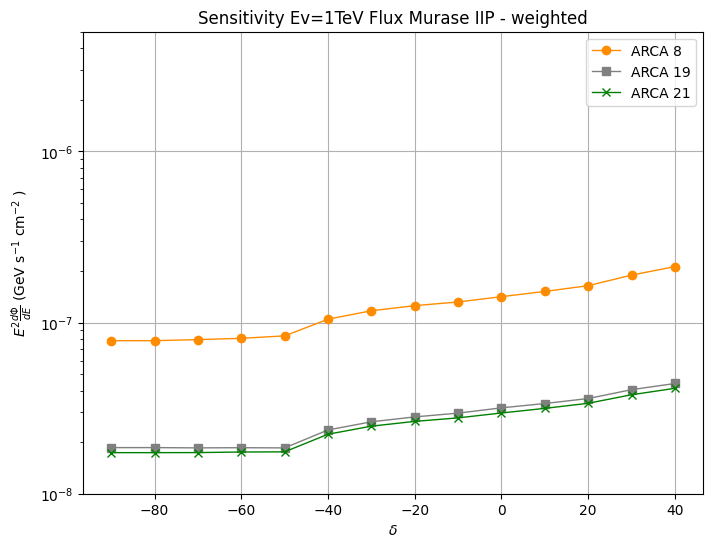

In [23]:
# Plot 1: Sensibilità (Flux Murase)
plt.figure(figsize=(8, 6))
plt.plot(delta_list, sensitivity_arca8, marker='o', color='darkorange', linewidth=1, label="ARCA 8")
plt.plot(delta_list, sensitivity_arca19, color='grey', marker='s', linewidth=1, label="ARCA 19")
plt.plot(delta_list, sensitivity_weighted_26,marker='x', color='green', linewidth=1, label="ARCA 21")


plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")
plt.ylim(1e-8,5e-6)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Flux Murase IIP - weighted')
plt.legend()
plt.show()

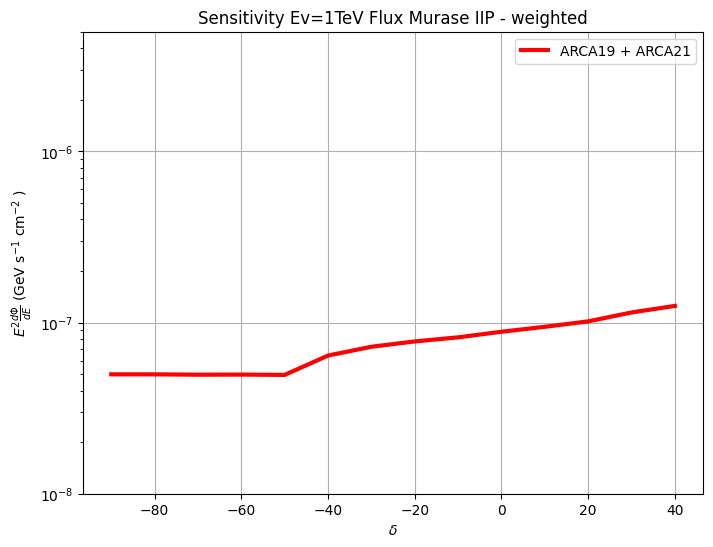

In [36]:
# Distanza 1Mpc
d = 1 * 3.086e24  # cm
d_m = 1 * 3.086e22  # m per calcrate
data_tot =  np.loadtxt("flux_IIp_tot.txt", skiprows=1)

E_fixed = 1.07461e3
Ev_tot = data_tot[:,0]
dN_dEv_tot = data_tot[:,1]
Ev = Ev_tot[Ev_tot==E_fixed]
dN_dEv= dN_dEv_tot[Ev_tot==E_fixed]

flux_tot = Ev**2 *  dN_dEv * 2 * d_m**2 / d**2


'''MRF_ARCA19_21 =  [
    239.704, 239.704, 240.523, 242.798, 243.891,
    303.934, 336.046, 356.207, 371.491, 394.178,
    416.284, 443.383, 495.863, 538.654
]'''


MRF_ARCA19_21 = [1180.43, 1180.43, 1174.52, 1176.11, 1171.27, 1519.71, 1710.21,
 1837.41, 1941.4, 2093.01, 2237.58, 2406.38, 2713.25, 2962.48]





sensitivity_arca19_21 =  flux_tot * MRF_ARCA19_21



# Definizione degli angoli δ
delta_list = np.linspace(-90, 40, len(MRF_tot_3))
#sin_delta = np.sin(np.radians(delta_list))

# Plot 1: Sensibilità (Flux Murase)
plt.figure(figsize=(8, 6))
plt.plot(delta_list, sensitivity_arca19_21, color='red', linewidth=3, label="ARCA19 + ARCA21")
#plt.plot(delta_list, sensitivity_weighted_26,marker='x', color='green', linewidth=1, label="ARCA 21")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")
plt.ylim(1e-8,5e-6)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Flux Murase IIP - weighted')
plt.legend()
plt.show()



print()


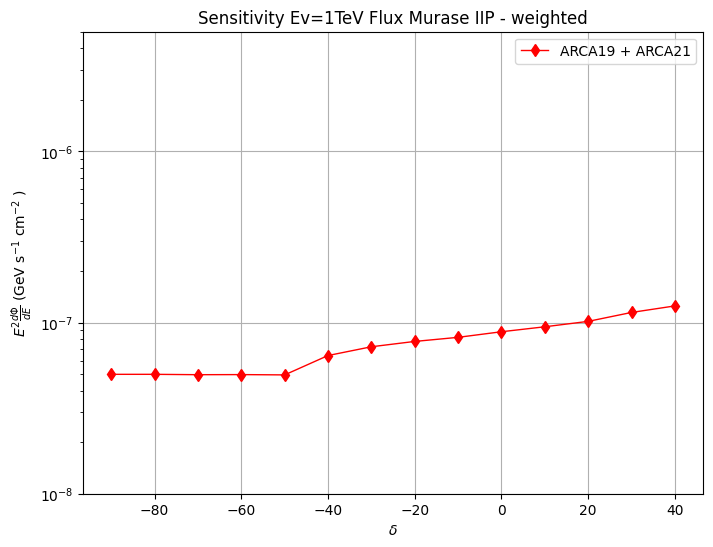

In [38]:
# Plot 1: Sensibilità (Flux Murase)
plt.figure(figsize=(8, 6))
plt.plot(delta_list, sensitivity_arca19_21, color='red', marker='d', linewidth=1, label="ARCA19 + ARCA21")


plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")
plt.ylim(1e-8,5e-6)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Flux Murase IIP - weighted')
plt.legend()
plt.show()


ARCA8+ARCA19+ARCA21

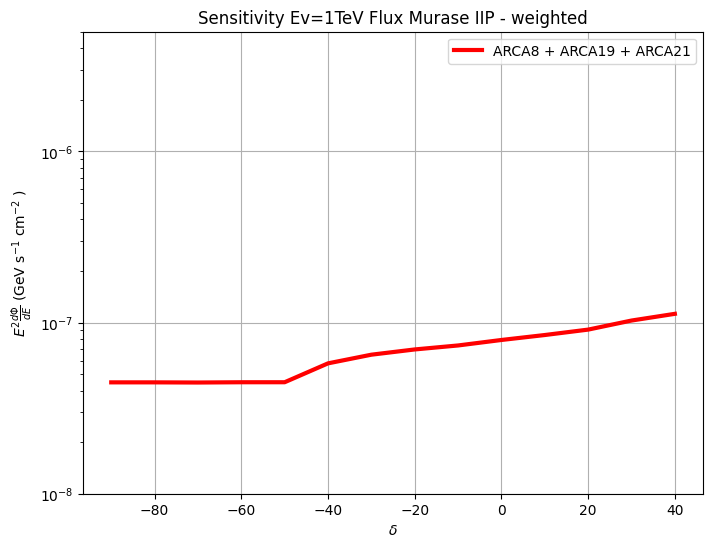

In [4]:
# Distanza 1Mpc
d = 1 * 3.086e24  # cm
d_m = 1 * 3.086e22  # m per calcrate
data_tot =  np.loadtxt("flux_IIp_tot.txt", skiprows=1)

E_fixed = 1.07461e3
Ev_tot = data_tot[:,0]
dN_dEv_tot = data_tot[:,1]
Ev = Ev_tot[Ev_tot==E_fixed]
dN_dEv= dN_dEv_tot[Ev_tot==E_fixed]

flux_tot = Ev**2 *  dN_dEv * 2 * d_m**2 / d**2


'''MRF_ARCA19_21 =  [
    239.704, 239.704, 240.523, 242.798, 243.891,
    303.934, 336.046, 356.207, 371.491, 394.178,
    416.284, 443.383, 495.863, 538.654
]'''


MRF_ARCA8_19_21 = [1059.51, 1059.51, 1057.21, 1061.09, 1061.25, 1368.06, 1537.17, 1649.58, 1740.51, 1873.76, 2002.83, 2154.24, 2433.54, 2663.66]




sensitivity_arca8_19_21 =  flux_tot * MRF_ARCA8_19_21



# Definizione degli angoli δ
delta_list = np.linspace(-90, 40, len(MRF_ARCA8_19_21))
#sin_delta = np.sin(np.radians(delta_list))

# Plot 1: Sensibilità (Flux Murase)
plt.figure(figsize=(8, 6))
plt.plot(delta_list, sensitivity_arca8_19_21, color='red',  linewidth=3, label="ARCA8 + ARCA19 + ARCA21")
#plt.plot(delta_list, sensitivity_arca19_21, color='blue', marker='s', linewidth=1, label="ARCA19 + ARCA21")
#plt.plot(delta_list, sensitivity_weighted_26,marker='x', color='green', linewidth=1, label="ARCA 21")

plt.xlabel(r"$\delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")
plt.ylim(1e-8,5e-6)
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Flux Murase IIP - weighted')
plt.legend()
plt.show()



print()
